In [27]:
import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [38]:
filepath = "../data/raw/S2_composite_2022.tif"

with rasterio.open(filepath) as src:
    data_22 = src.read()



In [36]:
filepath_24 = "../data/raw/S2_composite_2024.tif"

with rasterio.open(filepath_24) as src:
    data_24 = src.read()

In [39]:
#check data_22

print(f"Type: {type(data_22)}")
print(f"Dimensions: {data_22.ndim}")
print(f"Shape: {data_22.shape}")
print(f"Data type: {data_22.dtype}")

#check data_24

print(f"Type: {type(data_24)}")
print(f"Dimensions: {data_24.ndim}")
print(f"Shape: {data_24.shape}")
print(f"Data type: {data_24.dtype}")

Type: <class 'numpy.ndarray'>
Dimensions: 3
Shape: (12, 1566, 1064)
Data type: float64
Type: <class 'numpy.ndarray'>
Dimensions: 3
Shape: (12, 1566, 1064)
Data type: float64


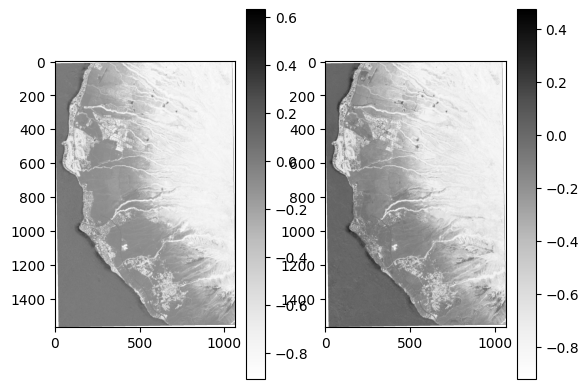

In [53]:
#define function for normalized burn ratio

def NBR(array):
    
    NIR = array[3]
    SWIR = array[5]
    NBR = (NIR-SWIR)/(NIR+SWIR)

    return NBR

test_22 = NBR(data_22)
test_24 = NBR(data_24)

fig, (ax1, ax2) = plt.subplots(1,2)
im1 = ax1.imshow(test_22, cmap = "Greys")
im2 = ax2.imshow(test_24, cmap = "Greys")
fig.colorbar(im1, ax=ax1)
fig.colorbar(im2, ax=ax2)                   